In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
base_path = "../data"

In [5]:
df_train = pd.read_csv(os.path.join(base_path, 'fraudTrain.csv'), index_col=0)
df_test = pd.read_csv(os.path.join(base_path, 'fraudTest.csv'), index_col=0)
df_full = pd.concat([df_train, df_test], axis=0)

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Full data shape: {df_full.shape}")

Train shape: (1296675, 22)
Test shape: (555719, 22)
Full data shape: (1852394, 22)


In [6]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
df_full.nunique()

trans_date_trans_time    1819551
cc_num                       999
merchant                     693
category                      14
amt                        60616
first                        355
last                         486
gender                         2
street                       999
city                         906
state                         51
zip                          985
lat                          983
long                         983
city_pop                     891
job                          497
dob                          984
trans_num                1852394
unix_time                1819583
merch_lat                1754157
merch_long               1809753
is_fraud                       2
dtype: int64

In [15]:
def plot_split_histograms(df, feature, target, figsize=(10, 4), bins=20, colors=['tab:blue', 'tab:red']):
    labels = sorted(df[target].unique())
    n_labels = len(labels)
    fig, axes = plt.subplots(1, n_labels, figsize=figsize)
    if n_labels == 1:
        axes = [axes]
    for i, label in enumerate(labels):
        subset = df[df[target] == label]
        subset[feature].plot(
            kind='hist',
            ax=axes[i],
            color=colors[i % len(colors)],
            edgecolor='black',
            bins=bins)
        target_name = "Legitimate" if label == 0 else "Fraud"
        axes[i].set_title(f'Status: {target_name} (n={len(subset)})', fontsize=12,fontweight='bold')
        axes[i].set_xlabel(feature.replace('_', ' ').capitalize())
        axes[i].set_ylabel('Transaction Count')
        axes[i].legend()
        axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [16]:
def plot_boxplot(df, feature, target, colors=['tab:blue', 'tab:red']):
    plt.figure(figsize=(6, 6))
    sns.boxplot(data=df, x=target, y=feature, palette=colors, hue=target, legend=False)
    plt.title(f'Comparison of {feature.capitalize()} by Transaction Status', fontsize=14, pad=15)
    plt.xlabel('Transaction Type (0: Legitimate, 1: Fraud)', fontsize=12)
    plt.ylabel(f'{feature.capitalize()}', fontsize=12)
    plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [17]:
def age_extraction(df):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year
    return df
df_full = age_extraction(df_full)

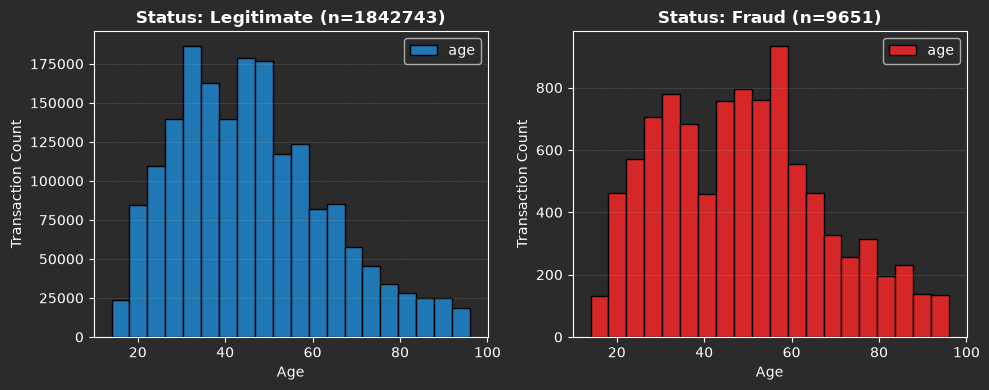

In [19]:
plot_split_histograms(df_full, 'age', 'is_fraud')

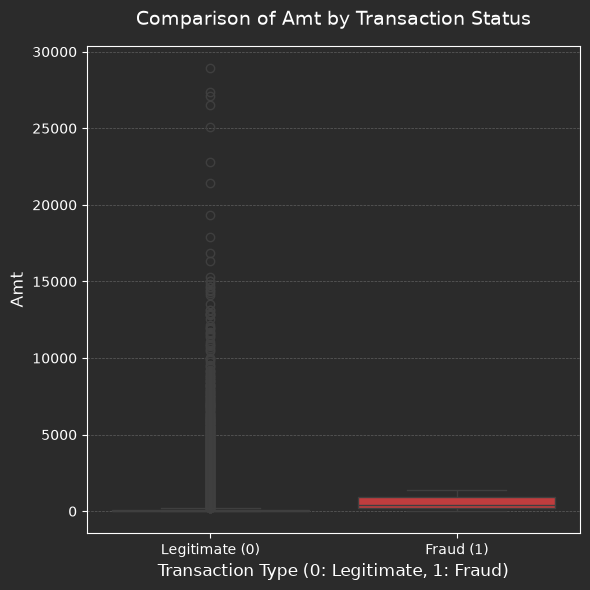

In [20]:
plot_boxplot(df_full, 'amt', 'is_fraud')

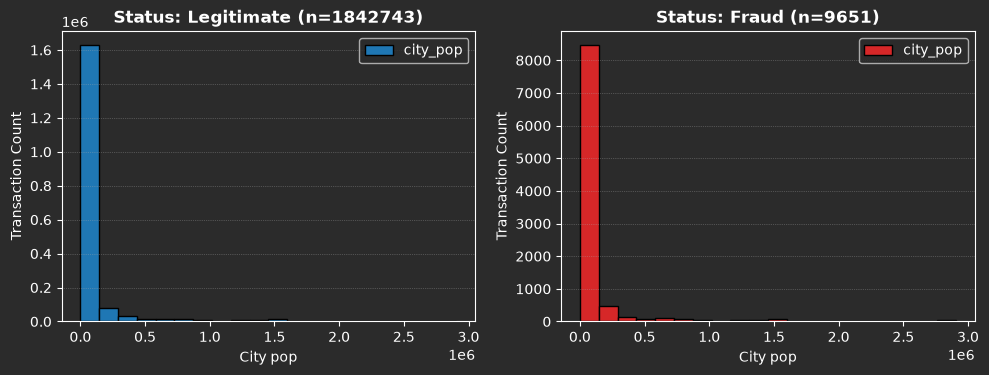

In [21]:
plot_split_histograms(df_full, 'city_pop', 'is_fraud')

In [24]:
def calculate_haversine(df):
    lat1, lon1 = np.radians(df['lat']), np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

In [25]:
df_full['distance_km'] = calculate_haversine(df_full)

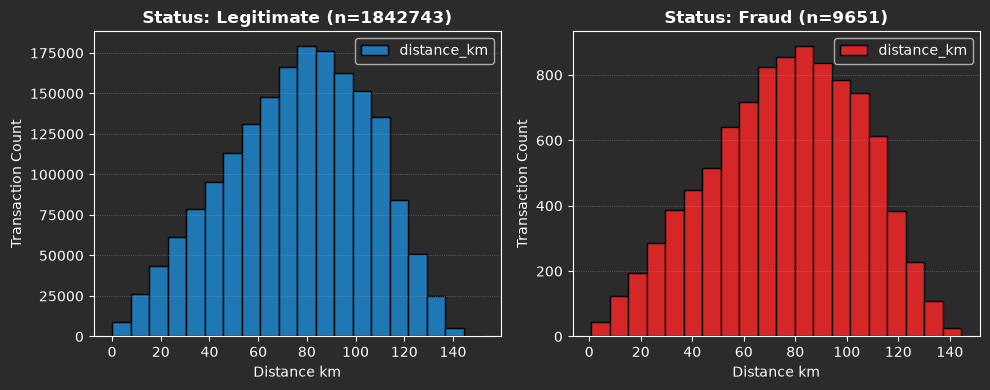

In [26]:
plot_split_histograms(df_full, 'distance_km', 'is_fraud')

In [30]:
def datetime_extraction(df):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    return df

df_full = datetime_extraction(df_full)

In [31]:
def plot_split_bar_charts_sorted(df, feature, target, figsize=(16, 8), colors=['tab:blue', 'tab:red']):
    sorted_order = sorted(df[feature].unique())
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    labels = [0, 1]
    for i, label in enumerate(labels):
        subset = df[df[target] == label]
        sns.countplot(
            data=subset,
            y=feature,
            ax=axes[i],
            order=sorted_order,
            hue=feature,
            legend=False,
            palette=[colors[i]] * len(sorted_order),
            edgecolor='black'
        )
        status_text = "Legitimate" if label == 0 else "Fraud"
        axes[i].set_title(f'Status: {status_text} (n={len(subset)})', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Transaction Count')
        axes[i].set_ylabel(feature.replace('_', ' ').capitalize())
        axes[i].grid(axis='x', linestyle=':', alpha=0.6)

    plt.suptitle(f'Behavioral Analysis: Transaction Count by {feature.capitalize()}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

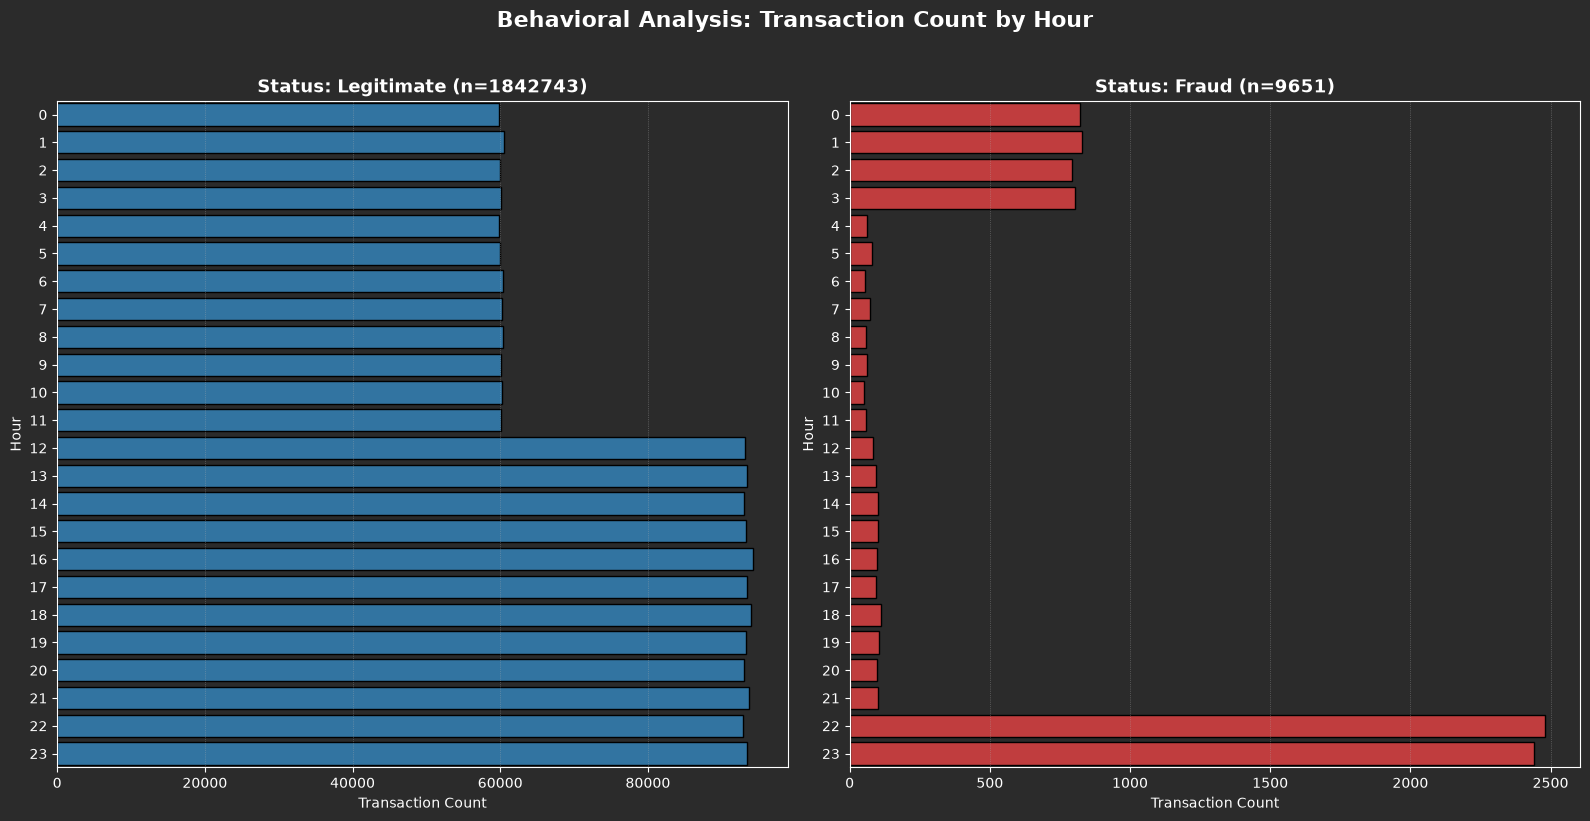

In [32]:
df_full = datetime_extraction(df_full)
plot_split_bar_charts_sorted(df_full, 'hour', 'is_fraud')

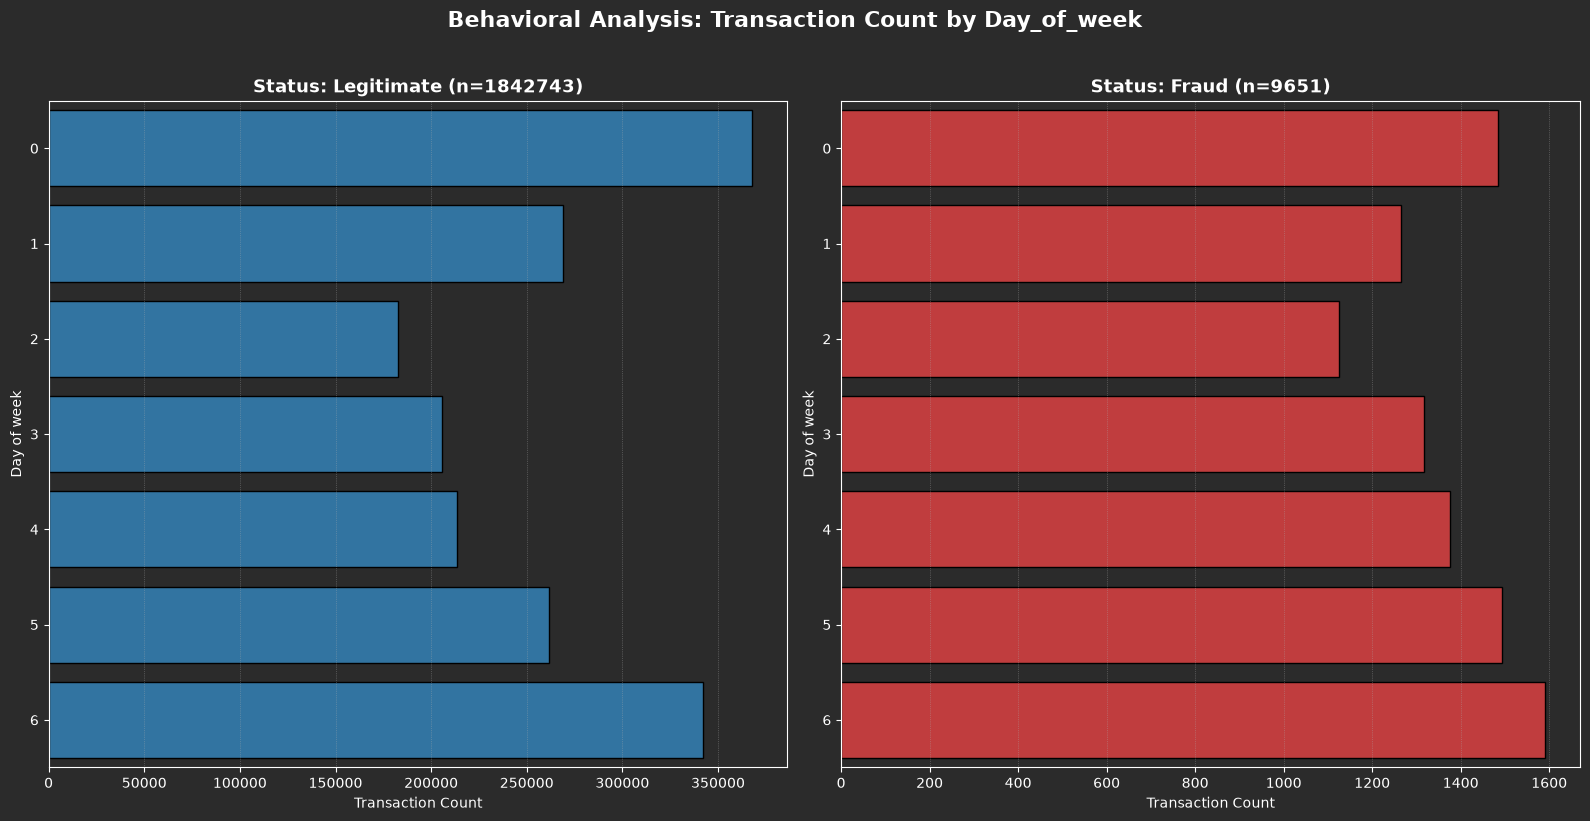

In [33]:
plot_split_bar_charts_sorted(df_full, 'day_of_week', 'is_fraud')

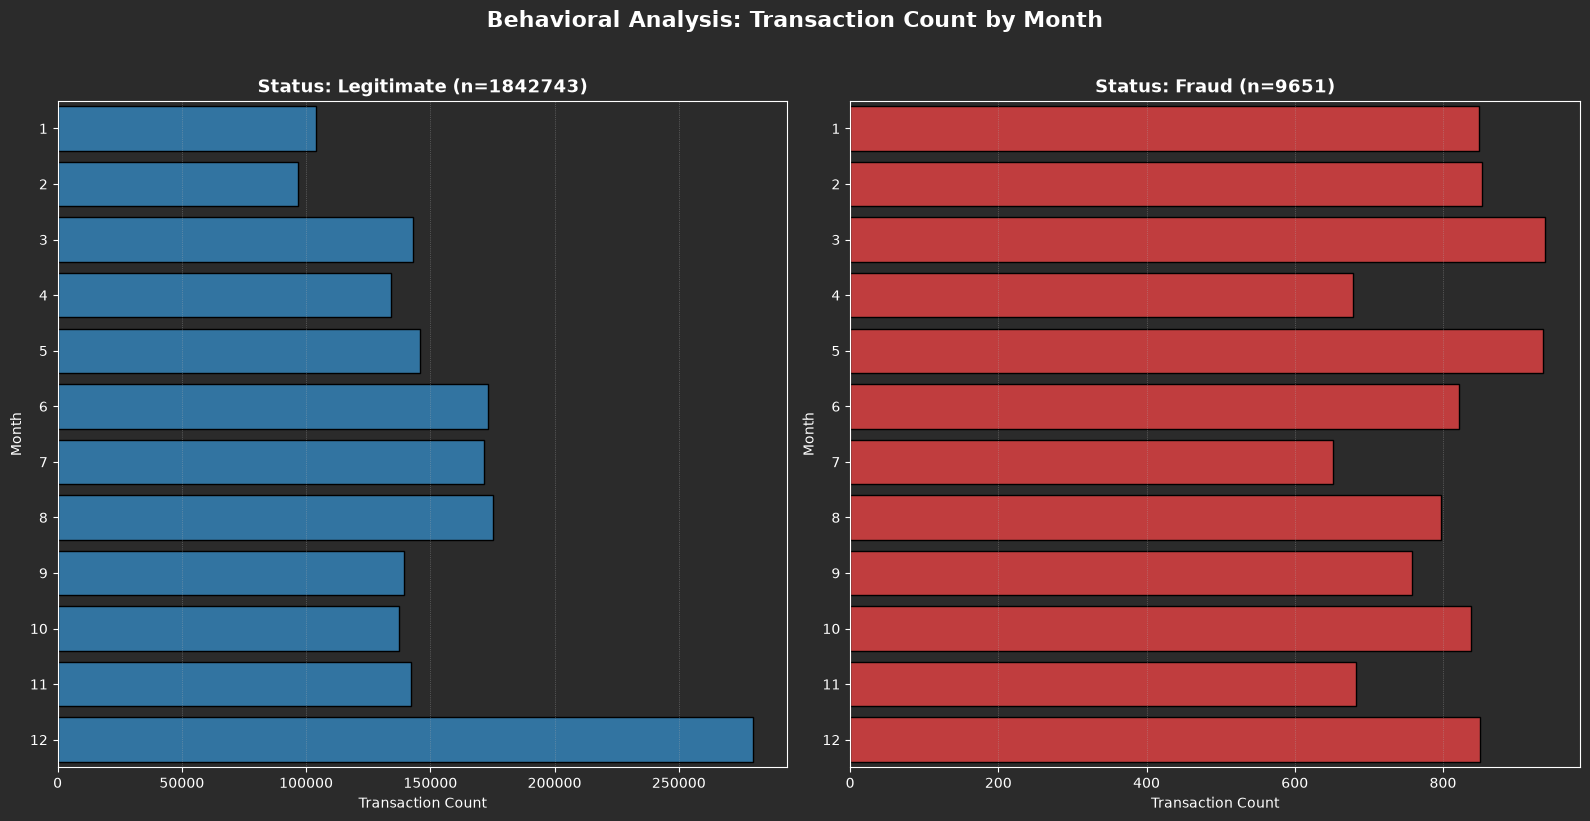

In [34]:
plot_split_bar_charts_sorted(df_full, 'month', 'is_fraud')

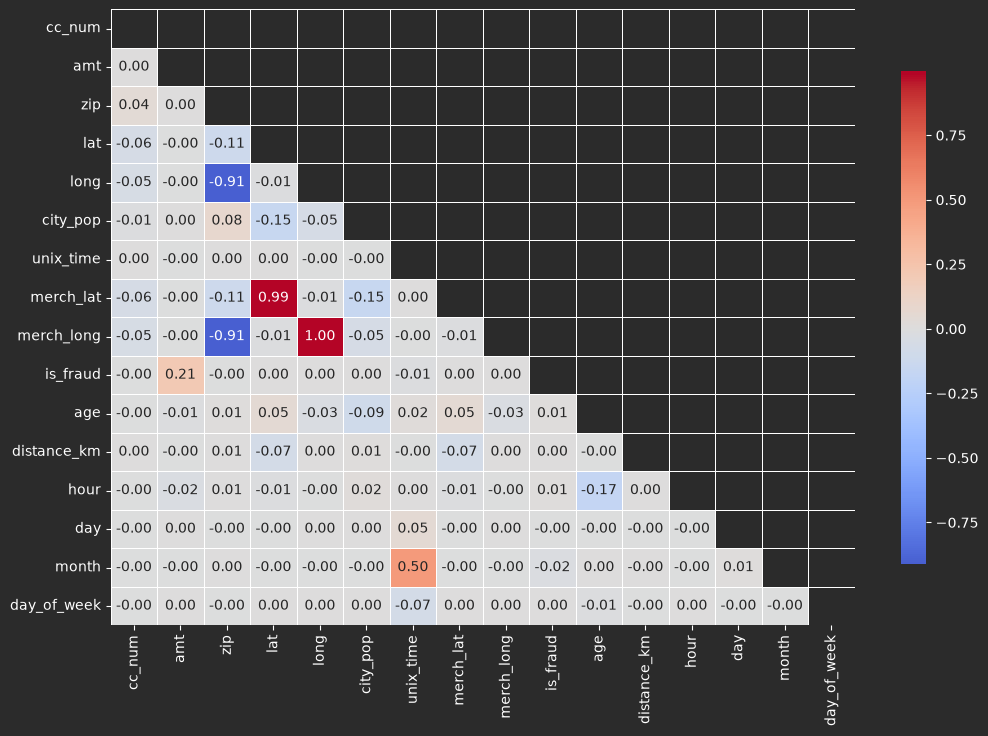

In [35]:
numeric_df = df_full.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8})
plt.show()

In [36]:
train_names = df_train[["first", "last"]].drop_duplicates()
test_names = df_test[["first", "last"]].drop_duplicates()

overlapping_names = train_names.merge(
    test_names, on=["first", "last"], how="inner"
).drop_duplicates()
test_rows_with_train_name = df_test.merge(
    overlapping_names, on=["first", "last"], how="inner"
)

print(f"Unique (first, last) pairs in train: {len(train_names):,}")
print(f"Unique (first, last) pairs in test: {len(test_names):,}")
print(f"Unique train pairs also present in test: {len(overlapping_names):,}")
print(
    f"Test rows whose (first, last) pair occurs in train: "
    f"{len(test_rows_with_train_name):,} / {len(df_test):,} "
    f"({len(test_rows_with_train_name) / len(df_test):.2%})"
)

overlapping_names.head()

Unique (first, last) pairs in train: 973
Unique (first, last) pairs in test: 917
Unique train pairs also present in test: 901
Test rows whose (first, last) pair occurs in train: 555,556 / 555,719 (99.97%)


,first,last
0,Jennifer,Banks
1,Stephanie,Gill
2,Edward,Sanchez
3,Jeremy,White
4,Tyler,Garcia
